# Kagome and extended-kagome band structures

Extract the real part of the column explicitly titled `Eigenfrequency` from the COMSOL CSV exports. Frequency units are read from the column header and converted to Hz.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defs import (
    band_frequency_matrix,
    calculate_bandwidth,
    extract_band_structure,
    plot_band_structure,
    set_axes_size,
)

In [15]:
data_dir = Path('../../../data/simulation')
out_dir = Path('../../../output/paper_upload')

# Plot output toggles
SHOW_PLOT_DECORATIONS = False # False hides labels, tick labels, legends, and titles.
SAVE_PLOT = True  # False displays figures without saving them.

band_files = {
    'Kagome': 'extkag_0_shb.csv',
    'Extended kagome': 'extkag_1_shb.csv',
}

max_bands = {
    'Kagome': 3,
    'Extended kagome': 14,
}

flat_band_indices = {
    'Kagome': -1,
    'Extended kagome': -1,
}

output_filenames = {
    'Kagome': 'kagome_band.pdf',
    'Extended kagome': 'extkag_band.pdf',
}


## Extract the Eigenfrequency column

In [16]:
# COMSOL parsing and band-organization helpers are defined in defs.py.

In [17]:
band_data = {}

for label, filename in band_files.items():
    band_limit = max_bands.get(label)
    dataset = extract_band_structure(
        data_dir / filename, max_bands=band_limit
    )
    band_data[label] = dataset

    mode_counts = np.asarray([
        len(frequencies)
        for frequencies in dataset['frequencies_by_b_hz'].values()
    ])
    print(
        f'{label}: {len(dataset["eigenfrequency_hz"])} points, '
        f'{len(dataset["frequencies_by_b_hz"])} b values, '
        f'{mode_counts.min()}–{mode_counts.max()} modes per b'
    )

Kagome: 144 points, 48 b values, 3–3 modes per b
Extended kagome: 672 points, 48 b values, 14–14 modes per b


## Calculate the flat-band bandwidths

The bandwidth is the difference between the maximum and minimum flat-band frequencies along the full $\Gamma$–K–M–$\Gamma$ sweep.

In [18]:
# Bandwidth helpers are defined in defs.py.

In [19]:
flat_band_statistics = {
    label: calculate_bandwidth(band_data[label], band_index)
    for label, band_index in flat_band_indices.items()
}

for label, statistics in flat_band_statistics.items():
    print(
        f'{label} flat band: '
        f'{statistics["minimum_hz"]:.6g}–'
        f'{statistics["maximum_hz"]:.6g} Hz; '
        f'bandwidth = {statistics["bandwidth_hz"]:.6g} Hz'
    )

Kagome flat band: 14294–14596.7 Hz; bandwidth = 302.63 Hz
Extended kagome flat band: 14413.4–14413.4 Hz; bandwidth = 0.000771061 Hz


## Plot the extracted band structures

At each `b` value, only the configured number of lowest-frequency extended-kagome modes is retained. The plotting style follows the compact paper figures: secondary bands are light gray and the flat band is highlighted in black.

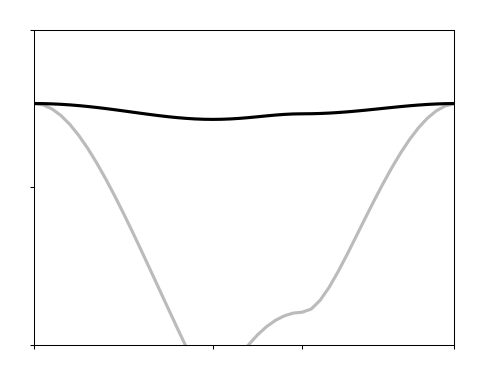

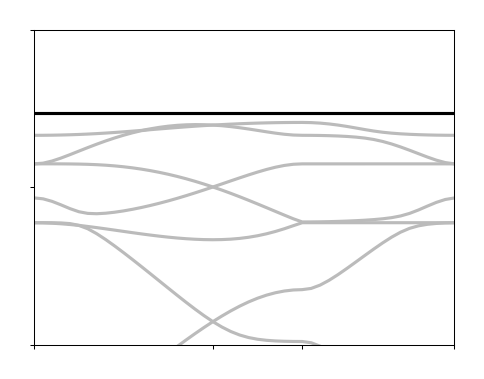

In [20]:
for label, highlighted_band in flat_band_indices.items():
    fig, ax = plot_band_structure(
        band_data[label], highlighted_band
    )
    if not SHOW_PLOT_DECORATIONS:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    if SAVE_PLOT:
        fig.savefig(out_dir / output_filenames[label])
    plt.show()